**Libs**

In [ ]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
import glob

print("Hello World")

Hello World


**Synthetic Data Generation**

In [2]:
def create_synthetic_data():
    # Create a dark gray background (simulating concrete/asphalt)
    img = np.ones((400, 400, 3), dtype=np.uint8) * 60 
    
    # Draw a "Real Crack" (Thin, irregular, continuous white line)
    cv2.line(img, (50, 350), (200, 200), (255, 255, 255), 2)
    cv2.line(img, (200, 200), (350, 50), (255, 255, 255), 2)
    cv2.line(img, (200, 200), (220, 180), (255, 255, 255), 2) # Branch
    
    # Draw a "Marker" (Thick, geometric shape drawn by a human)
    cv2.circle(img, (300, 300), 40, (255, 255, 255), 4) # Thick white circle
    cv2.arrowedLine(img, (300, 250), (300, 150), (255, 255, 255), 3, tipLength=0.3)
    
    # Create the "True Ground Truth" mask (ONLY the crack is white)
    true_mask = np.zeros((400, 400), dtype=np.uint8)
    cv2.line(true_mask, (50, 350), (200, 200), 255, 2)
    cv2.line(true_mask, (200, 200), (350, 50), 255, 2)
    cv2.line(true_mask, (200, 200), (220, 180), 255, 2)
    
    return img, true_mask

original_img, ground_truth_mask = create_synthetic_data()

# Simulate a "Bad Model Prediction" (Model detects BOTH crack and marker)
bad_prediction = ground_truth_mask.copy()
cv2.circle(bad_prediction, (300, 300), 40, 255, 4) # Model falsely predicted the circle
cv2.arrowedLine(bad_prediction, (300, 250), (300, 150), 255, 3) 
# Add some random noise pixels the model might predict
bad_prediction[10:15, 10:15] = 255 
bad_prediction[380:390, 380:390] = 255

**Actual Images**

**Preprocessing**

In [3]:
# Technique A: CLAHE (Contrast Limited Adaptive Histogram Equalization)
# Why: Enhances local contrast, making faint cracks more visible without blowing out the bright markers.
gray_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2GRAY)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
clahe_img = clahe.apply(gray_img)
clahe_img_3ch = cv2.cvtColor(clahe_img, cv2.COLOR_GRAY2BGR)

# Technique B: Hard Negative Augmentation (The Ultimate Fix for Markers)
# Why: We intentionally draw fake markers on the training image, but LEAVE THEM OUT of the mask.
# This forces the model to learn: "Bright geometric shapes != crack".
augmented_img = original_img.copy()
cv2.rectangle(augmented_img, (50, 50), (150, 150), (255, 255, 255), 3) # Fake marker
# Note: The mask for this image remains 'ground_truth_mask' (no rectangle in the mask!)

array([[[60, 60, 60],
        [60, 60, 60],
        [60, 60, 60],
        ...,
        [60, 60, 60],
        [60, 60, 60],
        [60, 60, 60]],

       [[60, 60, 60],
        [60, 60, 60],
        [60, 60, 60],
        ...,
        [60, 60, 60],
        [60, 60, 60],
        [60, 60, 60]],

       [[60, 60, 60],
        [60, 60, 60],
        [60, 60, 60],
        ...,
        [60, 60, 60],
        [60, 60, 60],
        [60, 60, 60]],

       ...,

       [[60, 60, 60],
        [60, 60, 60],
        [60, 60, 60],
        ...,
        [60, 60, 60],
        [60, 60, 60],
        [60, 60, 60]],

       [[60, 60, 60],
        [60, 60, 60],
        [60, 60, 60],
        ...,
        [60, 60, 60],
        [60, 60, 60],
        [60, 60, 60]],

       [[60, 60, 60],
        [60, 60, 60],
        [60, 60, 60],
        ...,
        [60, 60, 60],
        [60, 60, 60],
        [60, 60, 60]]], shape=(400, 400, 3), dtype=uint8)

**Post-processing**

In [5]:
# Technique C: Morphological Opening
# Why: Removes small, isolated white pixels (noise) while preserving the shape of larger objects.
kernel = np.ones((3, 3), np.uint8)
opened_mask = cv2.morphologyEx(bad_prediction, cv2.MORPH_OPEN, kernel, iterations=2)

# Technique D: Connected Component Analysis (Area Filtering)
# Why: Cracks are long and connected. Noise or small marker fragments are small. 
# We can measure the pixel area of every white blob and delete blobs that are too small.
cleaned_mask = np.zeros_like(bad_prediction)
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(bad_prediction, connectivity=8)

MIN_AREA = 50 # Ignore any white blob smaller than 50 pixels
for i in range(1, num_labels): # Start at 1 to skip the background (label 0)
    area = stats[i, cv2.CC_STAT_AREA]
    if area > MIN_AREA:
        cleaned_mask[labels == i] = 255
        
# Technique E: Morphological Skeletonization (Optional but powerful for cracks)
# Why: Reduces thick, messy crack predictions down to a 1-pixel wide centerline, 
# making it easier to distinguish from thick marker circles.
def skeletonize(img):
    size = np.size(img)
    skel = np.zeros(img.shape, np.uint8)
    element = cv2.getStructuringElement(cv2.MORPH_CROSS, (3, 3))
    done = False
    while not done:
        eroded = cv2.erode(img, element)
        temp = cv2.dilate(eroded, element)
        temp = cv2.subtract(img, temp)
        skel = cv2.bitwise_or(skel, temp)
        img = eroded.copy()
        zeros = size - cv2.countNonZero(img)
        if zeros == size:
            done = True
    return skel

skeleton_mask = skeletonize(cleaned_mask)

**Viz**

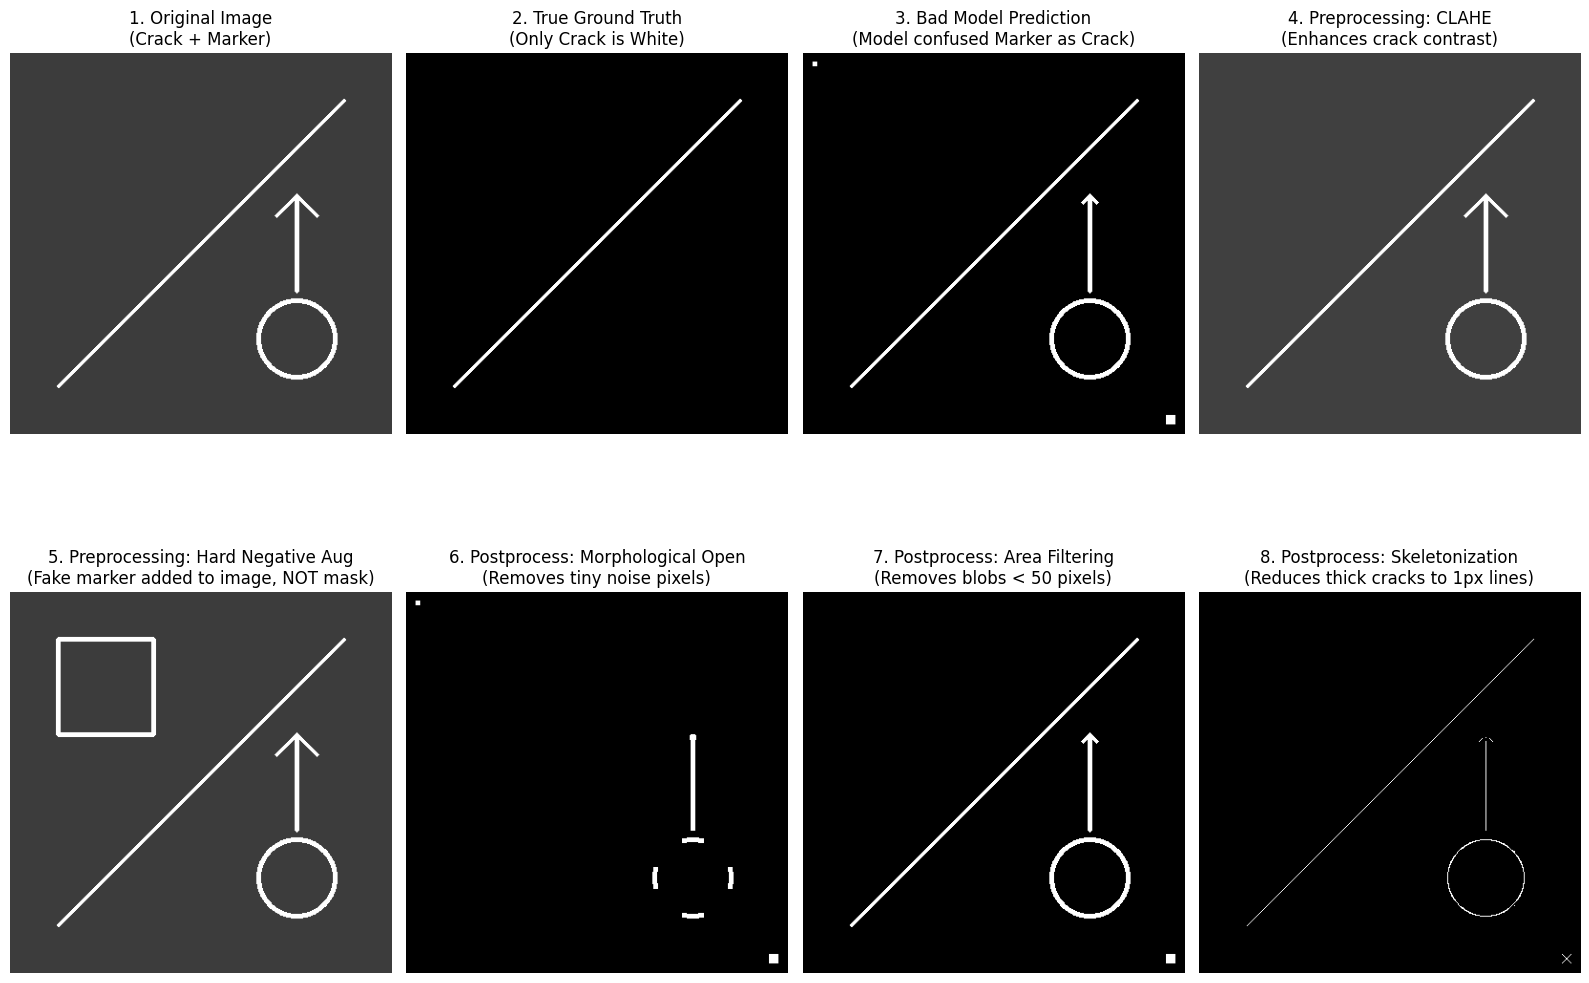

In [6]:
plt.figure(figsize=(16, 12))

# Row 1: The Problem & The Goal
plt.subplot(2, 4, 1)
plt.title("1. Original Image\n(Crack + Marker)")
plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(2, 4, 2)
plt.title("2. True Ground Truth\n(Only Crack is White)")
plt.imshow(ground_truth_mask, cmap='gray')
plt.axis('off')

plt.subplot(2, 4, 3)
plt.title("3. Bad Model Prediction\n(Model confused Marker as Crack)")
plt.imshow(bad_prediction, cmap='gray')
plt.axis('off')

# Row 2: The Solutions
plt.subplot(2, 4, 4)
plt.title("4. Preprocessing: CLAHE\n(Enhances crack contrast)")
plt.imshow(clahe_img_3ch)
plt.axis('off')

plt.subplot(2, 4, 5)
plt.title("5. Preprocessing: Hard Negative Aug\n(Fake marker added to image, NOT mask)")
plt.imshow(cv2.cvtColor(augmented_img, cv2.COLOR_BGR2RGB))
plt.axis('off')


plt.subplot(2, 4, 6)
plt.title("6. Postprocess: Morphological Open\n(Removes tiny noise pixels)")
plt.imshow(opened_mask, cmap='gray')
plt.axis('off')

plt.subplot(2, 4, 7)
plt.title("7. Postprocess: Area Filtering\n(Removes blobs < 50 pixels)")
plt.imshow(cleaned_mask, cmap='gray')
plt.axis('off')

plt.subplot(2, 4, 8)
plt.title("8. Postprocess: Skeletonization\n(Reduces thick cracks to 1px lines)")
plt.imshow(skeleton_mask, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()